In [1]:
pip install opencv-python numpy pandas scikit-learn scikit-image matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


--- 🖼️ Displaying First 5 Sample Processed Images ---


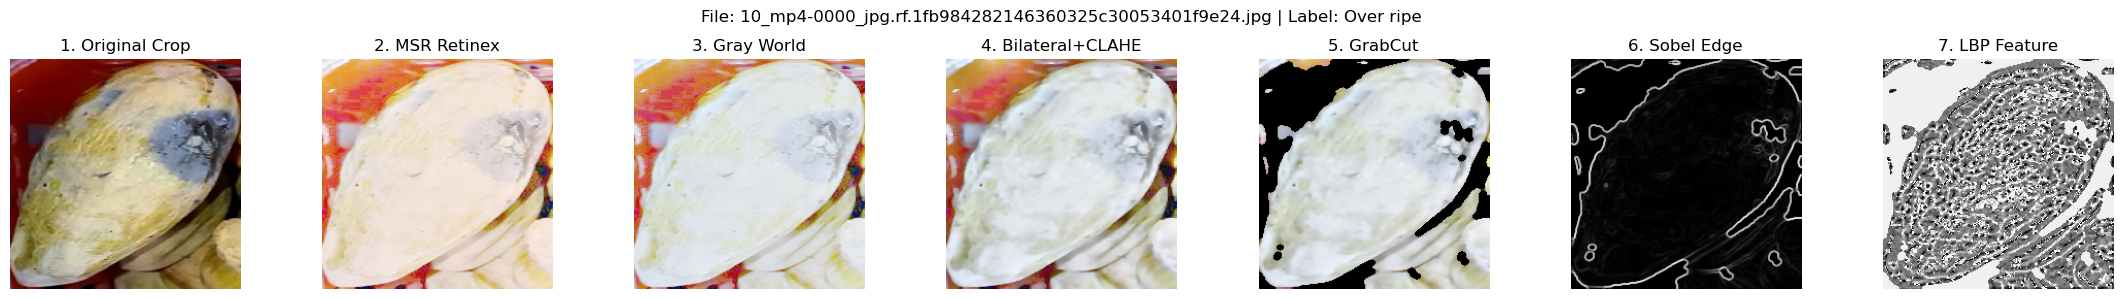

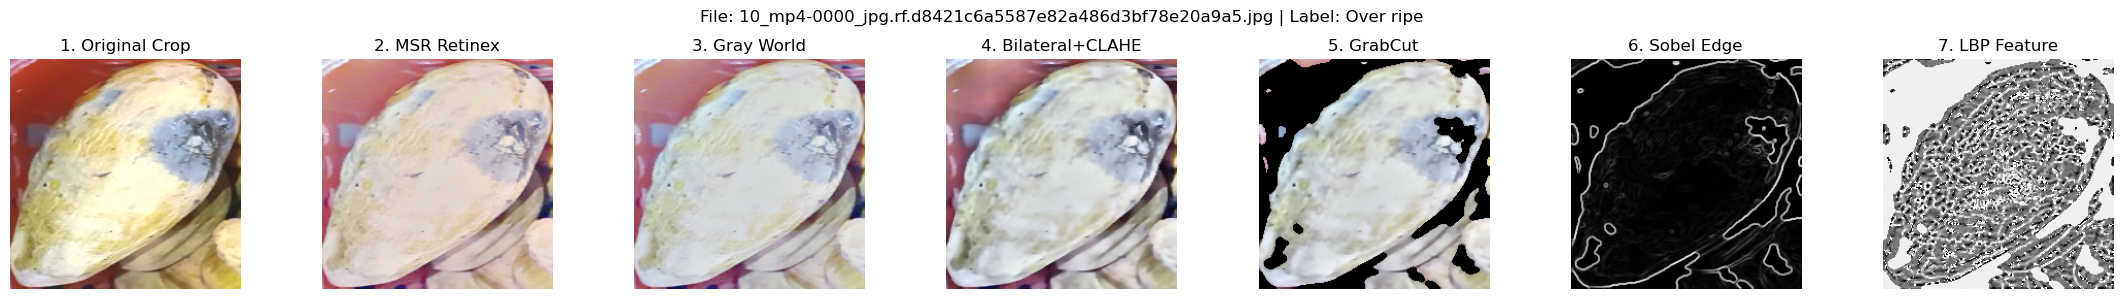

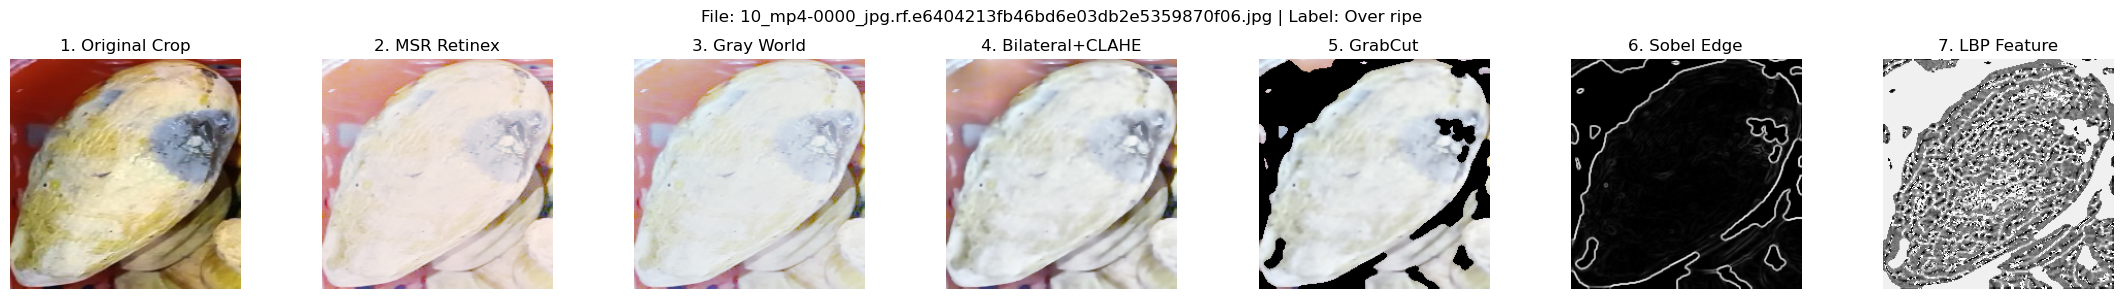

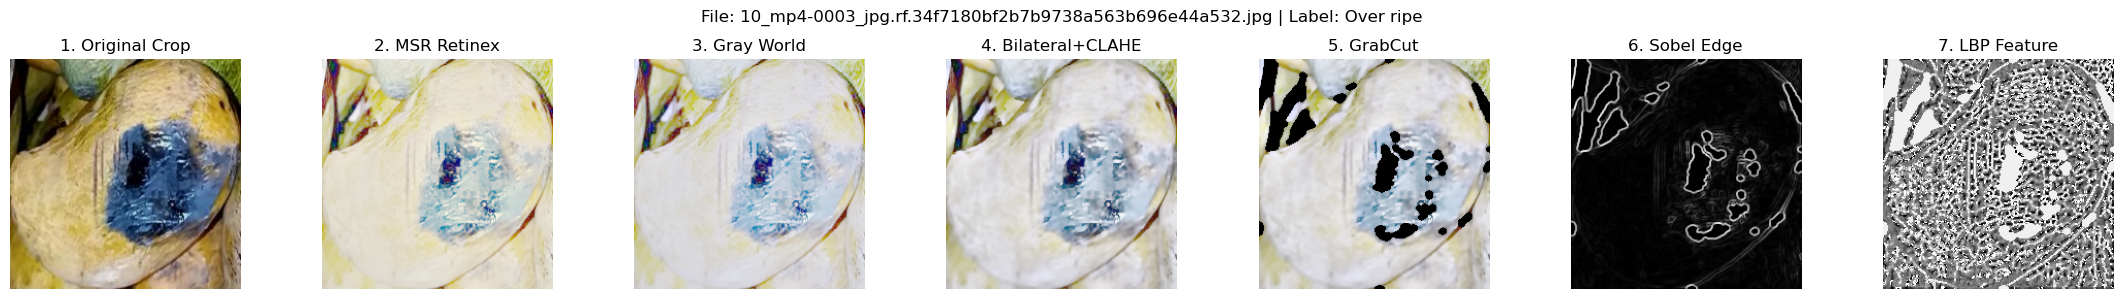

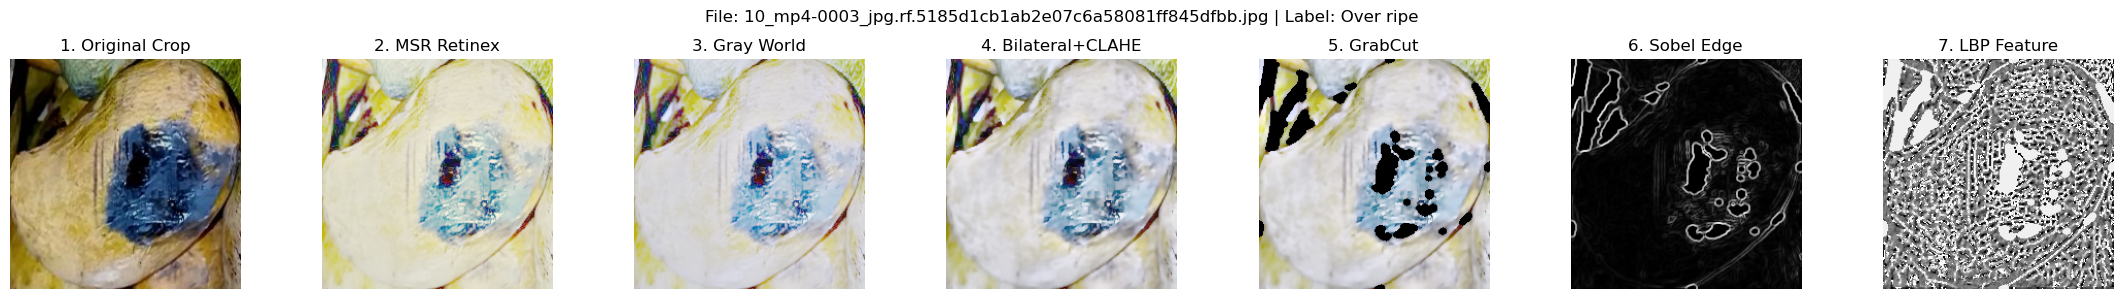


⚡ Parallel Processing 'train' set (4932 images)...


Progress [train]:   0%|          | 0/4932 [00:00<?, ?it/s]


⚡ Parallel Processing 'valid' set (453 images)...


Progress [valid]:   0%|          | 0/453 [00:00<?, ?it/s]


⚡ Parallel Processing 'test' set (228 images)...


Progress [test]:   0%|          | 0/228 [00:00<?, ?it/s]


--- Split Sizes ---
Training: (53083, 18) (53083,)
Validation: (4791, 18) (4791,)
Testing: (2632, 18) (2632,)


In [4]:
%matplotlib inline
import xml.etree.ElementTree as ET
from pathlib import Path
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

# ==========================================
# Exact Image Processing Pipeline
# ==========================================

def multi_scale_retinex(img, sigmas=[15, 80]):
    img_float = img.astype(np.float32) + 1.0
    msr = np.zeros_like(img_float)
    for sigma in sigmas:
        blur = cv.GaussianBlur(img_float, (0, 0), sigma)
        msr += np.log10(img_float) - np.log10(blur + 1e-5)
    msr = msr / len(sigmas)
    for i in range(3):
        msr_c = msr[:, :, i]
        min_v, max_v = np.min(msr_c), np.max(msr_c)
        if max_v > min_v:
            msr[:, :, i] = (msr_c - min_v) / (max_v - min_v) * 255.0
    return np.clip(msr, 0, 255).astype(np.uint8)

def color_constancy_shades_of_gray(img, p=6):
    img_float = img.astype(np.float32) + 1e-5
    power_img = np.power(img_float, p)
    m = np.power(np.mean(power_img, axis=(0, 1)), 1/p)
    e = m / (np.linalg.norm(m) + 1e-5)
    gray_val = 1.0 / np.sqrt(3)
    gain = gray_val / (e + 1e-5)
    return np.clip(img_float * gain, 0, 255).astype(np.uint8)

def apply_bilateral_filter(img):
    return cv.bilateralFilter(img, d=5, sigmaColor=50, sigmaSpace=50)

def apply_clahe(channel):
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(channel)

def apply_grabcut(img):
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    blurred = cv.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv.threshold(blurred, 0, 1, cv.THRESH_BINARY + cv.THRESH_OTSU)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7))
    mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)
    return img * mask[:, :, np.newaxis], mask

def apply_sobel(gray_img):
    sobelx = cv.Sobel(gray_img, cv.CV_64F, 1, 0, ksize=3)
    sobely = cv.Sobel(gray_img, cv.CV_64F, 0, 1, ksize=3)
    magnitude = cv.magnitude(sobelx, sobely)
    return cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

def process_single_image(img_path):
    try:
        img = cv.imread(str(img_path))
        if img is None:
            return None

        xml_path = img_path.with_suffix(".xml")
        if not xml_path.exists():
            return None

        results = []
        tree = ET.parse(xml_path)
        root = tree.getroot()

        for obj in root.findall("object"):
            label = obj.find("name").text
            b = obj.find("bndbox")

            xmin, ymin = int(b.find("xmin").text), int(b.find("ymin").text)
            xmax, ymax = int(b.find("xmax").text), int(b.find("ymax").text)

            if xmax <= xmin or ymax <= ymin:
                continue

            crop = img[ymin:ymax, xmin:xmax]
            if crop.size == 0:
                continue

            crop = cv.resize(crop, (224, 224))

            msr_img = multi_scale_retinex(crop)
            cc_img = color_constancy_shades_of_gray(msr_img)
            denoised_img = apply_bilateral_filter(cc_img)

            hsv = cv.cvtColor(denoised_img, cv.COLOR_BGR2HSV)
            h, s, v = cv.split(hsv)
            v_clahe = apply_clahe(v)
            clahe_img = cv.cvtColor(cv.merge([h, s, v_clahe]), cv.COLOR_HSV2BGR)

            grabcut_img, _ = apply_grabcut(clahe_img)
            gray_seg = cv.cvtColor(grabcut_img, cv.COLOR_BGR2GRAY)

            radius = 2
            n_points = 8 * radius
            lbp = local_binary_pattern(gray_seg, n_points, radius, method="uniform")
            
            n_bins = n_points + 2
            hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)

            results.append((hist, label))

        return results
    except Exception:
        return None


# ==========================================
# 🖼️ STEP 1: VISUAL PREVIEW (FIRST 5 IMAGES)
# ==========================================

DATASET_PATH = Path.home() / "Downloads" / "image processing" / "mango_dataset"
if not DATASET_PATH.exists():
    DATASET_PATH = Path("./Downloads/image processing/mango_dataset")

sample_files = list((DATASET_PATH / "train").glob("*.jpg"))[:5]

print("--- 🖼️ Displaying First 5 Sample Processed Images ---")
for img_path in sample_files:
    img = cv.imread(str(img_path))
    xml_path = img_path.with_suffix(".xml")
    if img is None or not xml_path.exists():
        continue

    tree = ET.parse(xml_path)
    root = tree.getroot()
    obj = root.find("object")
    if obj is None:
        continue

    label = obj.find("name").text
    b = obj.find("bndbox")
    xmin, ymin = int(b.find("xmin").text), int(b.find("ymin").text)
    xmax, ymax = int(b.find("xmax").text), int(b.find("ymax").text)

    crop = img[ymin:ymax, xmin:xmax]
    crop = cv.resize(crop, (224, 224))

    msr_img = multi_scale_retinex(crop)
    cc_img = color_constancy_shades_of_gray(msr_img)
    denoised_img = apply_bilateral_filter(cc_img)

    hsv = cv.cvtColor(denoised_img, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)
    v_clahe = apply_clahe(v)
    clahe_img = cv.cvtColor(cv.merge([h, s, v_clahe]), cv.COLOR_HSV2BGR)

    grabcut_img, _ = apply_grabcut(clahe_img)
    gray_seg = cv.cvtColor(grabcut_img, cv.COLOR_BGR2GRAY)
    sobel_img = apply_sobel(gray_seg)

    radius = 2
    n_points = 8 * radius
    lbp = local_binary_pattern(gray_seg, n_points, radius, method="uniform")

    fig, axes = plt.subplots(1, 7, figsize=(22, 3))
    axes[0].imshow(cv.cvtColor(crop, cv.COLOR_BGR2RGB))
    axes[0].set_title("1. Original Crop")
    axes[1].imshow(cv.cvtColor(msr_img, cv.COLOR_BGR2RGB))
    axes[1].set_title("2. MSR Retinex")
    axes[2].imshow(cv.cvtColor(cc_img, cv.COLOR_BGR2RGB))
    axes[2].set_title("3. Gray World")
    axes[3].imshow(cv.cvtColor(clahe_img, cv.COLOR_BGR2RGB))
    axes[3].set_title("4. Bilateral+CLAHE")
    axes[4].imshow(cv.cvtColor(grabcut_img, cv.COLOR_BGR2RGB))
    axes[4].set_title("5. GrabCut")
    axes[5].imshow(sobel_img, cmap="gray")
    axes[5].set_title("6. Sobel Edge")
    axes[6].imshow(lbp, cmap="gray")
    axes[6].set_title("7. LBP Feature")

    for ax in axes:
        ax.axis("off")

    plt.suptitle(f"File: {img_path.name} | Label: {label}")
    plt.tight_layout()
    plt.show()


# ==========================================
# ⚡ STEP 2: FAST MULTI-CORE PROCESSING
# ==========================================

datasets = {}

for split in ["train", "valid", "test"]:
    folder = DATASET_PATH / split
    if not folder.exists():
        continue

    image_files = list(folder.glob("*.jpg"))
    print(f"\n⚡ Parallel Processing '{split}' set ({len(image_files)} images)...")

    out = Parallel(n_jobs=-1, backend="threading")(
        delayed(process_single_image)(p) for p in tqdm(image_files, desc=f"Progress [{split}]")
    )

    X_split, y_split = [], []
    for res in out:
        if res:
            for feat, lbl in res:
                X_split.append(feat)
                y_split.append(lbl)

    datasets[split] = (np.array(X_split), np.array(y_split))

X_train, y_train = datasets["train"]
X_valid, y_valid = datasets["valid"]
X_test, y_test = datasets["test"]

print("\n--- Split Sizes ---")
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Testing:", X_test.shape, y_test.shape)

In [5]:
# =========================================================
# MODEL TRAINING & EVALUATION
# =========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

train_pred = svm_model.predict(X_train_scaled)
valid_pred = svm_model.predict(X_valid_scaled)
test_pred = svm_model.predict(X_test_scaled)

print("\n----- Accuracy Scores -----")
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Validation Accuracy:", accuracy_score(y_valid, valid_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

print("\n----- Classification Report -----")
print(classification_report(y_test, test_pred))


----- Accuracy Scores -----
Training Accuracy: 0.9634911365220504
Validation Accuracy: 0.9663953245668963
Testing Accuracy: 0.9703647416413373

----- Classification Report -----
              precision    recall  f1-score   support

   Over ripe       0.97      0.95      0.96       413
        Ripe       0.96      0.98      0.97      1113
      Unripe       0.98      0.97      0.98      1106

    accuracy                           0.97      2632
   macro avg       0.97      0.97      0.97      2632
weighted avg       0.97      0.97      0.97      2632



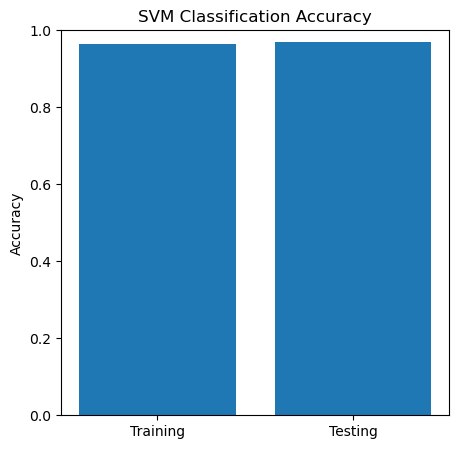

In [7]:
import matplotlib.pyplot as plt

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

plt.figure(figsize=(5, 5))
plt.bar(["Training", "Testing"], [train_acc, test_acc])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("SVM Classification Accuracy")
plt.show()

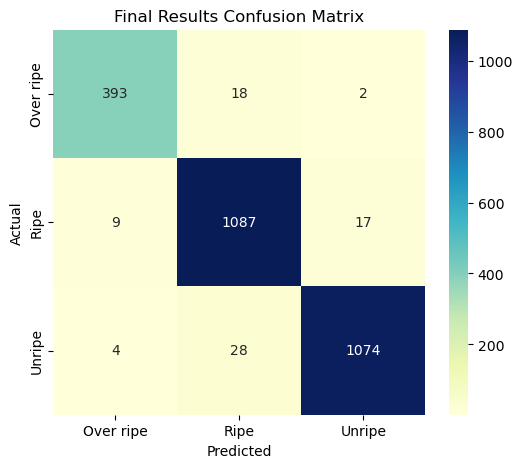

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, test_pred)
labels = np.unique(y_test)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Final Results Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [9]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, test_pred)
precision = precision_score(y_test, test_pred, average="weighted")
recall = recall_score(y_test, test_pred, average="weighted")
f1 = f1_score(y_test, test_pred, average="weighted")

print("----- Final Summary Metrics -----")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

----- Final Summary Metrics -----
Accuracy : 0.970
Precision: 0.971
Recall   : 0.970
F1 Score : 0.970
